In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


In [ ]:
!pip install ultralytics


In [4]:
!pip install pillow

In [5]:
!pip install opencv-python

In [6]:
!pip install pyyaml

In [7]:
import ultralytics
ultralytics.checks()

Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 41.1/112.6 GB disk)


In [8]:
import yaml


In [9]:
def write_yaml_file(data, file_path):
    """
    Write data to a YAML file.

    Args:
        data (dict): The data to write to the YAML file.
        file_path (str): The path to the YAML file.
    """
    if not isinstance(data, dict):
        raise ValueError("Data must be a dictionary.")

    if not isinstance(file_path, str):
        raise ValueError("File path must be a string.")

    # Ensure the directory exists
    import os
    directory = os.path.dirname(file_path)
    if not os.path.exists(directory):
        os.makedirs(directory)
    # Write the data to the YAML file
    with open(file_path, 'w') as file:
        yaml.dump(data, file, default_flow_style=False)

In [10]:
import os
from PIL import Image
import shutil

# YOLO formatında klasör yapısı oluştur
def prepare_yolo_structure():
    os.makedirs("datasets", exist_ok=True)
    os.makedirs("datasets/images/train", exist_ok=True)
    os.makedirs("datasets/labels/train", exist_ok=True)
    os.makedirs("datasets/images/val", exist_ok=True)
    os.makedirs("datasets/labels/val", exist_ok=True)

# YAML konfigürasyon dosyası oluştur
# data_yaml = {
#     'train': 'datasets/images/train',
#     'val': 'datasets/images/val',
#     'names': ['kanama', 'iskemi', 'normal'],
#     'nc': 3
# }



In [11]:
# write_yaml_file(data_yaml, 'data.yaml')

In [12]:
import numpy as np
import cv2

In [13]:
!git clone https://github.com/ramazanpolatsakarya/goruntuisleme.git  # clone


Cloning into 'goruntuisleme'...
remote: Enumerating objects: 23, done.
remote: Counting objects: 100% (23/23), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 23 (delta 0), reused 23 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (23/23), 6.91 MiB | 23.51 MiB/s, done.


In [14]:
# %cd yolov5
# !pip install -r requirements.txt  # install


In [15]:
# prompt: dicomutils import

!pip install pydicom
import pydicom


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 16.7 MB/s eta 0:00:00


In [16]:
from goruntuisleme.dicomutils import *
utils = dicomutils()


In [17]:
import pydicom
import tensorflow as tf


def load_dicom_data(folder_path, target_size=(256, 256)):
    """
    Load DICOM images from a folder and return as normalized numpy arrays
    """
    dicom_files = [f for f in os.listdir(folder_path) if f.endswith('.dcm')]
    images = []

    for file in dicom_files:
        try:
            # Load DICOM image
            ds = pydicom.dcmread(os.path.join(folder_path, file))
            img = ds.pixel_array

            # Normalize to 0-1 range
            if np.max(img) - np.min(img) > 0:  # Prevent division by zero
                img = (img - np.min(img)) / (np.max(img) - np.min(img))
            else:
                img = img.astype(float)

            # Resize if needed
            if img.shape != target_size:
                img = tf.image.resize(img[np.newaxis, ..., np.newaxis], target_size)
                img = img.numpy().squeeze()

            images.append(img)
        except Exception as e:
            print(f"Error processing {file}: {str(e)}")
            continue

    return np.array(images)


In [18]:
# kanama_images = load_dicom_data("Kanama Veri Seti/DICOM")
# kanama_masks =  load_dicom_data("Kanama Veri Seti/Mask/kanama")


In [19]:
# def convert_to_yolo_format(mask_path,class_id=0, img_size=256):
#     mask = np.array(Image.open(mask_path))
#     contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#     yolo_lines = []
#     for cnt in contours:
#         # Filter out small contours
#         if cv2.contourArea(cnt) < 10:  # Adjust threshold as needed
#             continue

#         x,y,w,h = cv2.boundingRect(cnt)
#         # YOLO formatı: [class_id, x_center, y_center, width, height] (normalize edilmiş)
#         x_center = (x + w/2) / img_size
#         y_center = (y + h/2) / img_size
#         width = w / img_size
#         height = h / img_size
#         yolo_lines.append(f"{class_id} {x_center} {y_center} {width} {height}")

#     return "\n".join(yolo_lines)

In [20]:
# def convert_to_yolo_format(masks, class_id=0, img_size=256):
#     """
#     Convert masks to YOLO format labels
#     """
#     yolo_labels = []

#     for mask in masks:
#         # Ensure mask is in uint8 format for findContours
#         mask_uint8 = (mask * 255).astype(np.uint8)

#         # Find contours in the mask
#         contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

#         label_lines = []
#         for cnt in contours:
#             # Filter out small contours
#             # if cv2.contourArea(cnt) < 10:  # Adjust threshold as needed
#             #     continue

#             # Get bounding box
#             x, y, w, h = cv2.boundingRect(cnt)

#             # Convert to YOLO format (normalized)
#             x_center = (x + w/2) / img_size
#             y_center = (y + h/2) / img_size
#             width = w / img_size
#             height = h / img_size

#             label_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

#         yolo_labels.append("\n".join(label_lines))

#     return yolo_labels

In [21]:
def convert_mask_to_yolo_seg(masks, class_id=0, img_size=256):
    """
    Convert binary masks to YOLO segmentation format (polygon points)
    Handles either a single mask or an array of masks
    """
    all_labels = []

    # Handle case where masks is a list/array of masks
    if isinstance(masks, np.ndarray) and masks.ndim > 2:
        # Process each mask individually
        for mask in masks:
            all_labels.append(process_single_mask(mask, class_id, img_size))
        return all_labels
    else:
        # Process a single mask
        return [process_single_mask(masks, class_id, img_size)]

def process_single_mask(mask, class_id=0, img_size=256):
    """Process a single binary mask to YOLO segmentation format"""
    # Convert mask to uint8 format for findContours
    mask_uint8 = (mask * 255).astype(np.uint8)

    # Ensure mask is single channel
    if mask_uint8.ndim > 2:
        # If mask has more than 2 dimensions, convert to grayscale
        mask_uint8 = cv2.cvtColor(mask_uint8, cv2.COLOR_RGB2GRAY)

    # Find contours in the mask
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    label_lines = []
    for cnt in contours:
        # Filter out small contours
        if cv2.contourArea(cnt) < 10:  # Adjust threshold as needed
            continue

        # Create polygon points
        points = []
        for point in cnt:
            x, y = point[0]
            # Normalize coordinates
            x_norm = x / img_size
            y_norm = y / img_size
            points.extend([x_norm, y_norm])

        # Format as YOLO segmentation line: class_id x1 y1 x2 y2 ...
        if points:  # Make sure points isn't empty
            points_str = " ".join([f"{p:.6f}" for p in points])
            label_lines.append(f"{class_id} {points_str}")

    return "\n".join(label_lines)

In [22]:

import pydicom
import tensorflow as tf


def load_mask_data(dicom_folder, overlay_folder, target_size=(256, 256)):
    """
    Load both DICOM images and corresponding mask overlays
    """
    dicom_files = [f for f in os.listdir(dicom_folder) if f.endswith('.dcm')]
    images = []
    masks = []
    filenames = []  # Store filenames for reference

    for file in dicom_files:
        try:
            # Load DICOM image
            ds = pydicom.dcmread(os.path.join(dicom_folder, file))
            img = ds.pixel_array

            # Normalize to 0-1 range
            if np.max(img) - np.min(img) > 0:  # Prevent division by zero
                img = (img - np.min(img)) / (np.max(img) - np.min(img))
            else:
                img = img.astype(float)

            # Resize if needed
            if img.shape != target_size:
                img = tf.image.resize(img[np.newaxis, ..., np.newaxis], target_size)
                img = img.numpy().squeeze()

            # Load overlay mask
            overlay_path = os.path.join(overlay_folder, file.replace('.dcm', '.png'))
            print(f"Looking for mask at: {overlay_path}")

            if os.path.exists(overlay_path):
                mask = np.array(Image.open(overlay_path).convert('L'))
                mask = (mask > 0).astype(np.float32)  # Convert to binary mask

                # Resize mask if needed
                if mask.shape != target_size:
                    mask = tf.image.resize(mask[np.newaxis, ..., np.newaxis], target_size)
                    mask = mask.numpy().squeeze()

                images.append(img)
                masks.append(mask)
                filenames.append(file)
            else:
                print(f"Mask not found for {file}")

        except Exception as e:
            print(f"Error processing {file}: {str(e)}")
            continue

    return np.array(images), np.array(masks), filenames

In [23]:
def process_dataset(dicom_folder, mask_folder, class_id, class_name, split_ratio=0.8):
    """
    Process a dataset for a specific class (kanama, iskemi, normal)
    """
    print(f"Processing {class_name} dataset...")
    # Load the data
    images, masks, filenames = load_mask_data(dicom_folder, mask_folder)

    print(f"Loaded {len(images)} image-mask pairs for {class_name}")

    if len(images) == 0:
        print(f"No valid image-mask pairs found for {class_name}")
        return



    # Debug information
    print(f"Mask array shape: {masks.shape}")
    print(f"Mask data type: {masks.dtype}")

    # Convert masks to YOLO format
    yolo_labels = convert_mask_to_yolo_seg(masks, class_id)

    # Split into train/val sets
    split_idx = int(len(images) * split_ratio)
    train_indices = list(range(split_idx))
    val_indices = list(range(split_idx, len(images)))

    # Save images and labels
    for set_name, indices in [("train", train_indices), ("val", val_indices)]:
        for i, index in enumerate(indices):
            if index >= len(images):
                continue

            # Convert image to uint8 for saving
            img = images[index]
            img_uint8 = (img * 255).astype(np.uint8)

            # Handle grayscale images properly
            if len(img_uint8.shape) == 2:
                img_pil = Image.fromarray(img_uint8, mode='L')
            else:
                img_pil = Image.fromarray(img_uint8)

            # Save image
            img_filename = f"{class_name}_{i}.png"
            img_path = f"datasets/images/{set_name}/{img_filename}"
            img_pil.save(img_path)

            # Save label
            label_path = f"datasets/labels/{set_name}/{class_name}_{i}.txt"
            with open(label_path, "w") as f:
                f.write(yolo_labels[index])

            print(f"Saved {img_path} and corresponding label")

In [24]:
# prompt: colab google drive base dosya adresi

# Define the base path to your Google Drive directory
google_drive_base_path = "/content/gdrive/MyDrive/datasets/"
# Example usage
# Replace "your_folder_name" with the actual name of the folder in your Google Drive
# data_folder = os.path.join(google_drive_base_path, "your_folder_name")


In [25]:
 # Define class mapping
classes = {
        0: {"name": "kanama", "dicom": google_drive_base_path+"Kanama Veri Seti/DICOM", "mask": google_drive_base_path+"Kanama Veri Seti/MASK/kanama"},
        1: {"name": "iskemi", "dicom":google_drive_base_path+"Iskemi Veri Seti/DICOM", "mask": google_drive_base_path+"Iskemi Veri Seti/MASK/iskemi"},
}

In [26]:
# Örnek veri dönüşümü (Kanama veri seti için)
prepare_yolo_structure()

In [ ]:

# Process each class
for class_id, class_info in classes.items():
    process_dataset(
              class_info["dicom"],
              class_info["mask"],
              class_id,
              class_info["name"]
          )



In [28]:
# Create YAML configuration file
data_yaml = {
    'train': 'images/train',
    'val': 'images/val',
    'names': [class_info["name"] for _, class_info in classes.items()],
    'nc': len(classes),
    'task': 'segment'
}


In [29]:

# write_yaml_file(data_yaml, 'data.yaml')
with open( 'data.yaml', 'w') as file:
    yaml.dump(data_yaml, file, default_flow_style=False)

print("YAML configuration file created.")

YAML configuration file created.


In [30]:
import os
import glob

def check_yolo_dataset(dataset_dir):
    """Check for empty label files and mismatches between images and labels"""
    for split in ['train', 'val']:
        images_dir = os.path.join(dataset_dir, 'images', split)
        labels_dir = os.path.join(dataset_dir, 'labels', split)

        image_files = set([os.path.splitext(os.path.basename(f))[0]
                          for f in glob.glob(f"{images_dir}/*.png") + glob.glob(f"{images_dir}/*.jpg")])
        label_files = set([os.path.splitext(os.path.basename(f))[0]
                          for f in glob.glob(f"{labels_dir}/*.txt")])

        # Check for images without labels
        img_no_label = image_files - label_files
        if img_no_label:
            print(f"WARNING: {len(img_no_label)} images have no labels in {split} set")
            print(f"Examples: {list(img_no_label)[:5]}")

        # Check for labels without images
        label_no_img = label_files - image_files
        if label_no_img:
            print(f"WARNING: {len(label_no_img)} labels have no images in {split} set")
            print(f"Examples: {list(label_no_img)[:5]}")

        # Check for empty label files
        empty_labels = []
        for label in label_files:
            label_path = os.path.join(labels_dir, f"{label}.txt")
            if os.path.exists(label_path) and os.path.getsize(label_path) == 0:
                empty_labels.append(label)

        if empty_labels:
            print(f"WARNING: {len(empty_labels)} empty label files in {split} set")
            print(f"Examples: {empty_labels[:5]}")



In [31]:
# Call this function with your dataset directory
check_yolo_dataset("datasets")

Examples: ['kanama_443', 'kanama_506', 'kanama_84']


In [32]:
from ultralytics import YOLO

# Model seçimi (Segmentasyon için YOLOv8x-seg)
model = YOLO('yolov8x-seg.pt')  # Önceden eğitilmiş model

# Eğitim parametreleri
train_args = {
    'data': 'data.yaml',
    'epochs': 50,
    'batch': 8,
    'imgsz': 256,
    'device': '0' if tf.config.list_physical_devices('GPU') else 'cpu',
    'optimizer': 'Adam',
    'lr0': 0.001,
    'name': 'stroke_detection'
}

# Eğitimi başlat
results = model.train(**train_args)

100%|██████████| 137M/137M [00:00<00:00, 302MB/s]


Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=segment, mode=train, model=yolov8x-seg.pt, data=data.yaml, epochs=50, time=None, patience=100, batch=8, imgsz=256, save=True, save_period=-1, cache=False, device=0, workers=8, project=None, name=stroke_detection, exist_ok=False, pretrained=True, optimizer=Adam, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, line_width=None,

100%|██████████| 755k/755k [00:00<00:00, 21.3MB/s]


Overriding model.yaml nc=80 with nc=2

                   from  n    params  module                                       arguments                     
  0                  -1  1      2320  ultralytics.nn.modules.conv.Conv             [3, 80, 3, 2]                 
  1                  -1  1    115520  ultralytics.nn.modules.conv.Conv             [80, 160, 3, 2]               
  2                  -1  3    436800  ultralytics.nn.modules.block.C2f             [160, 160, 3, True]           
  3                  -1  1    461440  ultralytics.nn.modules.conv.Conv             [160, 320, 3, 2]              
  4                  -1  6   3281920  ultralytics.nn.modules.block.C2f             [320, 320, 6, True]           
  5                  -1  1   1844480  ultralytics.nn.modules.conv.Conv             [320, 640, 3, 2]              
  6                  -1  6  13117440  ultralytics.nn.modules.block.C2f             [640, 640, 6, True]           
  7                  -1  1   3687680  ultralytics

100%|██████████| 5.35M/5.35M [00:00<00:00, 88.8MB/s]


...

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   7%|▋         | 2/28 [00:00<00:10,  2.59it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 28/28 [00:05<00:00,  4.82it/s]


                   all        443        678      0.666      0.425      0.478       0.27      0.677      0.383      0.449      0.217
                kanama        219        388      0.788      0.508      0.592      0.348       0.75      0.448      0.543      0.269
                iskemi        224        290      0.544      0.342      0.365      0.192      0.605      0.317      0.355      0.166
Speed: 0.1ms preprocess, 5.9ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to runs/segment/stroke_detection


In [35]:
# prompt: model kaydet

# Save the trained model
model.export(format='onnx') # You can change the format if needed (e.g., 'torchscript', 'coreml')


Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)

PyTorch: starting from 'runs/segment/stroke_detection/weights/best.pt' with input shape (1, 3, 256, 256) BCHW and output shape(s) ((1, 38, 1344), (1, 32, 64, 64)) (137.2 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 277.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 348.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.8/280.8 MB 289.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 255.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 262.5 MB/s eta 0:00:00

requirements: AutoUpdate success ✅ 24.9s, installed 3 packages: ['onnx>=1.12.0', 'onnxslim', 'onnxruntime-gpu']
requirements: ⚠️ Restart runtime or rerun command for updates to take effect


ONNX: starting export with o

'runs/segment/stroke_detection/weights/best.onnx'

Ultralytics 8.3.108 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8x-seg summary (fused): 125 layers, 71,722,582 parameters, 0 gradients, 343.7 GFLOPs


val: Scanning /content/datasets/labels/val.cache... 443 images, 0 backgrounds, 0 corrupt: 100%|██████████| 443/443 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   0%|          | 0/56 [00:00<?, ?it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   2%|▏         | 1/56 [00:00<00:12,  4.36it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):   4%|▎         | 2/56 [00:00<00:13,  4.15it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 56/56 [00:10<00:00,  5.36it/s]


                   all        443        678      0.694      0.419      0.486       0.27      0.719      0.378      0.449      0.215
                kanama        219        388       0.81        0.5        0.6      0.347      0.751      0.436      0.537      0.266
                iskemi        224        290      0.578      0.338      0.372      0.193      0.687      0.321      0.361      0.164
Speed: 0.2ms preprocess, 17.8ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to runs/segment/stroke_detection2
mAP50-95: 0.2702

image 1/1 /content/datasets/images/val/iskemi_0.png: 256x256 1 iskemi, 28.3ms
Speed: 0.6ms preprocess, 28.3ms inference, 38.0ms postprocess per image at shape (1, 3, 256, 256)
Results saved to runs/segment/stroke_detection3


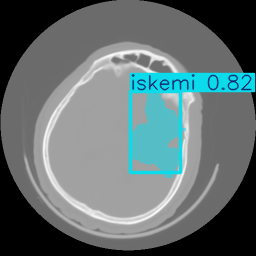

In [33]:
# Validation seti üzerinde değerlendirme
metrics = model.val()
print(f"mAP50-95: {metrics.box.map:.4f}")

# Örnek tahmin
sample_img = "datasets/images/val/iskemi_0.png"
results = model.predict(sample_img, save=True, imgsz=256)

# Sonuçları görselleştirme
for result in results:
    result.show()
    result.save("prediction.jpg")

In [36]:
!pip install pydicom gdcm pylibjpeg pylibjpeg-libjpeg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 91.9 MB/s eta 0:00:00


In [39]:
def kaydet(test_dir, img_file):
  img_path = os.path.join(test_dir, img_file)
  #hata kodu ekleyelim.

  img = pydicom.dcmread(img_path).pixel_array
  img = (img - np.min(img)) / (np.max(img) - np.min(img))
  img_pil = Image.fromarray((img*255).astype(np.uint8))
  img_pil.save("temp.png")
  results = model.predict("temp.png", imgsz=256)
  # Sonuçları kaydet
  for result in results:
      result.save_txt(google_drive_base_path + f"YarısmaVeriSeti_1.Oturum/MASKS_YOLO/Text/{img_file[:-4]}.txt")
      result.save(google_drive_base_path + f"YarısmaVeriSeti_1.Oturum/MASKS_YOLO/Mask/{img_file[:-4]}_vis.png")

In [40]:
test_dir = google_drive_base_path+ "YarısmaVeriSeti_1.Oturum/DICOM"
os.makedirs(google_drive_base_path+"YarısmaVeriSeti_1.Oturum/MASKS_YOLO/Mask", exist_ok=True)
os.makedirs(google_drive_base_path+"YarısmaVeriSeti_1.Oturum/MASKS_YOLO/Text", exist_ok=True)


In [41]:

for img_file in os.listdir(test_dir):
    try:
        if img_file.endswith('.dcm'):
          kaydet(test_dir, img_file)
    except Exception as e:
        print(f"Error processing {img_file}: {e}")
        continue



image 1/1 /content/temp.png: 256x256 (no detections), 28.7ms
Speed: 1.2ms preprocess, 28.7ms inference, 0.7ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/temp.png: 256x256 1 iskemi, 28.4ms
Speed: 0.8ms preprocess, 28.4ms inference, 2.8ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/temp.png: 256x256 (no detections), 29.3ms
Speed: 1.3ms preprocess, 29.3ms inference, 0.9ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/temp.png: 256x256 1 iskemi, 28.5ms
Speed: 0.9ms preprocess, 28.5ms inference, 2.2ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/temp.png: 256x192 1 kanama, 28.1ms
Speed: 0.9ms preprocess, 28.1ms inference, 2.0ms postprocess per image at shape (1, 3, 256, 192)

image 1/1 /content/temp.png: 256x256 (no detections), 29.6ms
Speed: 1.0ms preprocess, 29.6ms inference, 0.5ms postprocess per image at shape (1, 3, 256, 256)

image 1/1 /content/temp.png: 256x256 (no detections), 28.4ms
Speed